<a href="https://colab.research.google.com/github/rirfan3689/CSCI323-Spam-Detection/blob/main/notebooks/12_hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import files
import numpy as np
from scipy.sparse import load_npz

uploaded = files.upload()  # Upload ALL 13 files:
                           # Processed data (8 files):
                           # X_train.npz, X_test.npz, y_train.npy, y_test.npy
                           # sa_X_train.npz, sa_X_test.npz, sa_y_train.npy, sa_y_test.npy
                           # Baseline results (5 files):
                           # nb_results.json, lr_results.json, svm_results.json
                           # rf_results.json, sa_results.json

# Load UCI data
X_uci_train = load_npz('X_train.npz')
X_uci_test = load_npz('X_test.npz')
y_uci_train = np.load('y_train.npy', allow_pickle=True)
y_uci_test = np.load('y_test.npy', allow_pickle=True)

# Load SpamAssassin data
X_sa_train = load_npz('sa_X_train.npz')
X_sa_test = load_npz('sa_X_test.npz')
y_sa_train = np.load('sa_y_train.npy', allow_pickle=True)
y_sa_test = np.load('sa_y_test.npy', allow_pickle=True)

print("UCI Train:", X_uci_train.shape, "Test:", X_uci_test.shape)
print("SA Train:", X_sa_train.shape, "Test:", X_sa_test.shape)

Saving lr_results.json to lr_results.json
Saving nb_results.json to nb_results.json
Saving rf_results.json to rf_results.json
Saving sa_results.json to sa_results.json
Saving sa_X_test.npz to sa_X_test (1).npz
Saving sa_X_train.npz to sa_X_train (1).npz
Saving sa_y_test.npy to sa_y_test (1).npy
Saving sa_y_train.npy to sa_y_train (1).npy
Saving svm_results.json to svm_results.json
Saving X_test.npz to X_test (1).npz
Saving X_train.npz to X_train (1).npz
Saving y_test.npy to y_test (1).npy
Saving y_train.npy to y_train (1).npy
UCI Train: (4135, 5000) Test: (1034, 5000)
SA Train: (4263, 5000) Test: (1066, 5000)


In [8]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import numpy as np
import json

print("Libraries loaded!")

Libraries loaded!


In [9]:
param_grids = {
    'Naive Bayes': {
        'model': MultinomialNB(),
        'params': {
            'alpha': [0.1, 0.5, 1.0, 2.0, 5.0]
        }
    },
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.01, 0.1, 1.0, 10.0],
            'class_weight': [None, 'balanced']
        }
    },
    'SVM': {
        'model': SVC(kernel='linear', random_state=42),
        'params': {
            'C': [0.01, 0.1, 1.0, 10.0]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5]
        }
    }
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Parameter grids defined!")

Parameter grids defined!


In [10]:
print("=== Hyperparameter Tuning — UCI SMS Dataset ===\n")

uci_best_params = {}
uci_tuned_results = {}

for name, config in param_grids.items():
    print(f"Tuning {name}...")
    grid_search = GridSearchCV(
        config['model'],
        config['params'],
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )
    grid_search.fit(X_uci_train, y_uci_train)

    # Best parameters
    uci_best_params[name] = grid_search.best_params_
    print(f"  Best params: {grid_search.best_params_}")
    print(f"  Best CV F1:  {grid_search.best_score_:.4f}")

    # Evaluate on test set
    y_pred = grid_search.best_estimator_.predict(X_uci_test)
    uci_tuned_results[name] = {
        'best_params': grid_search.best_params_,
        'best_cv_f1': grid_search.best_score_,
        'accuracy': accuracy_score(y_uci_test, y_pred),
        'precision': precision_score(y_uci_test, y_pred, pos_label='spam'),
        'recall': recall_score(y_uci_test, y_pred, pos_label='spam'),
        'f1': f1_score(y_uci_test, y_pred, pos_label='spam')
    }
    print(f"  Test Accuracy:  {uci_tuned_results[name]['accuracy']:.4f}")
    print(f"  Test Precision: {uci_tuned_results[name]['precision']:.4f}")
    print(f"  Test Recall:    {uci_tuned_results[name]['recall']:.4f}")
    print(f"  Test F1:        {uci_tuned_results[name]['f1']:.4f}\n")

=== Hyperparameter Tuning — UCI SMS Dataset ===

Tuning Naive Bayes...
  Best params: {'alpha': 0.1}
  Best CV F1:  0.9409
  Test Accuracy:  0.9681
  Test Precision: 0.8769
  Test Recall:    0.8702
  Test F1:        0.8736

Tuning Logistic Regression...
  Best params: {'C': 10.0, 'class_weight': 'balanced'}
  Best CV F1:  0.9437
  Test Accuracy:  0.9749
  Test Precision: 0.8947
  Test Recall:    0.9084
  Test F1:        0.9015

Tuning SVM...
  Best params: {'C': 1.0}
  Best CV F1:  0.9408
  Test Accuracy:  0.9758
  Test Precision: 0.9569
  Test Recall:    0.8473
  Test F1:        0.8988

Tuning Random Forest...
  Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
  Best CV F1:  0.9275
  Test Accuracy:  0.9758
  Test Precision: 0.9818
  Test Recall:    0.8244
  Test F1:        0.8963



In [11]:
print("=== Hyperparameter Tuning — SpamAssassin Dataset ===\n")

sa_best_params = {}
sa_tuned_results = {}

for name, config in param_grids.items():
    print(f"Tuning {name}...")
    grid_search = GridSearchCV(
        config['model'],
        config['params'],
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )
    grid_search.fit(X_sa_train, y_sa_train)

    # Best parameters
    sa_best_params[name] = grid_search.best_params_
    print(f"  Best params: {grid_search.best_params_}")
    print(f"  Best CV F1:  {grid_search.best_score_:.4f}")

    # Evaluate on test set
    y_pred = grid_search.best_estimator_.predict(X_sa_test)
    sa_tuned_results[name] = {
        'best_params': grid_search.best_params_,
        'best_cv_f1': grid_search.best_score_,
        'accuracy': accuracy_score(y_sa_test, y_pred),
        'precision': precision_score(y_sa_test, y_pred, pos_label='spam'),
        'recall': recall_score(y_sa_test, y_pred, pos_label='spam'),
        'f1': f1_score(y_sa_test, y_pred, pos_label='spam')
    }
    print(f"  Test Accuracy:  {sa_tuned_results[name]['accuracy']:.4f}")
    print(f"  Test Precision: {sa_tuned_results[name]['precision']:.4f}")
    print(f"  Test Recall:    {sa_tuned_results[name]['recall']:.4f}")
    print(f"  Test F1:        {sa_tuned_results[name]['f1']:.4f}\n")

=== Hyperparameter Tuning — SpamAssassin Dataset ===

Tuning Naive Bayes...
  Best params: {'alpha': 0.1}
  Best CV F1:  0.9853
  Test Accuracy:  0.9878
  Test Precision: 0.9969
  Test Recall:    0.9645
  Test F1:        0.9805

Tuning Logistic Regression...
  Best params: {'C': 10.0, 'class_weight': 'balanced'}
  Best CV F1:  0.9919
  Test Accuracy:  0.9962
  Test Precision: 0.9970
  Test Recall:    0.9911
  Test F1:        0.9941

Tuning SVM...
  Best params: {'C': 10.0}
  Best CV F1:  0.9929
  Test Accuracy:  0.9953
  Test Precision: 0.9941
  Test Recall:    0.9911
  Test F1:        0.9926

Tuning Random Forest...
  Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  Best CV F1:  0.9853
  Test Accuracy:  0.9906
  Test Precision: 0.9940
  Test Recall:    0.9763
  Test F1:        0.9851



In [12]:
import json

# Load UCI baseline results from saved JSON files
uci_baseline_files = {
    'Naive Bayes': 'nb_results.json',
    'Logistic Regression': 'lr_results.json',
    'SVM': 'svm_results.json',
    'Random Forest': 'rf_results.json'
}

uci_baseline = {}
for name, filename in uci_baseline_files.items():
    with open(filename) as f:
        data = json.load(f)
        uci_baseline[name] = {
            'accuracy': data['accuracy'],
            'precision': data['precision'],
            'recall': data['recall'],
            'f1': data['f1']
        }

print("UCI baseline loaded:")
for name, results in uci_baseline.items():
    print(f"  {name}: F1={results['f1']:.4f}")

UCI baseline loaded:
  Naive Bayes: F1=0.8559
  Logistic Regression: F1=0.7798
  SVM: F1=0.8988
  Random Forest: F1=0.8833


In [13]:
# Load SpamAssassin baseline results
with open('sa_results.json') as f:
    sa_data = json.load(f)

sa_baseline = {}
for name, results in sa_data.items():
    sa_baseline[name] = {
        'accuracy': results['accuracy'],
        'precision': results['precision'],
        'recall': results['recall'],
        'f1': results['f1']
    }

print("SpamAssassin baseline loaded:")
for name, results in sa_baseline.items():
    print(f"  {name}: F1={results['f1']:.4f}")

SpamAssassin baseline loaded:
  Naive Bayes: F1=0.9712
  Logistic Regression: F1=0.9743
  SVM: F1=0.9926
  Random Forest: F1=0.9851


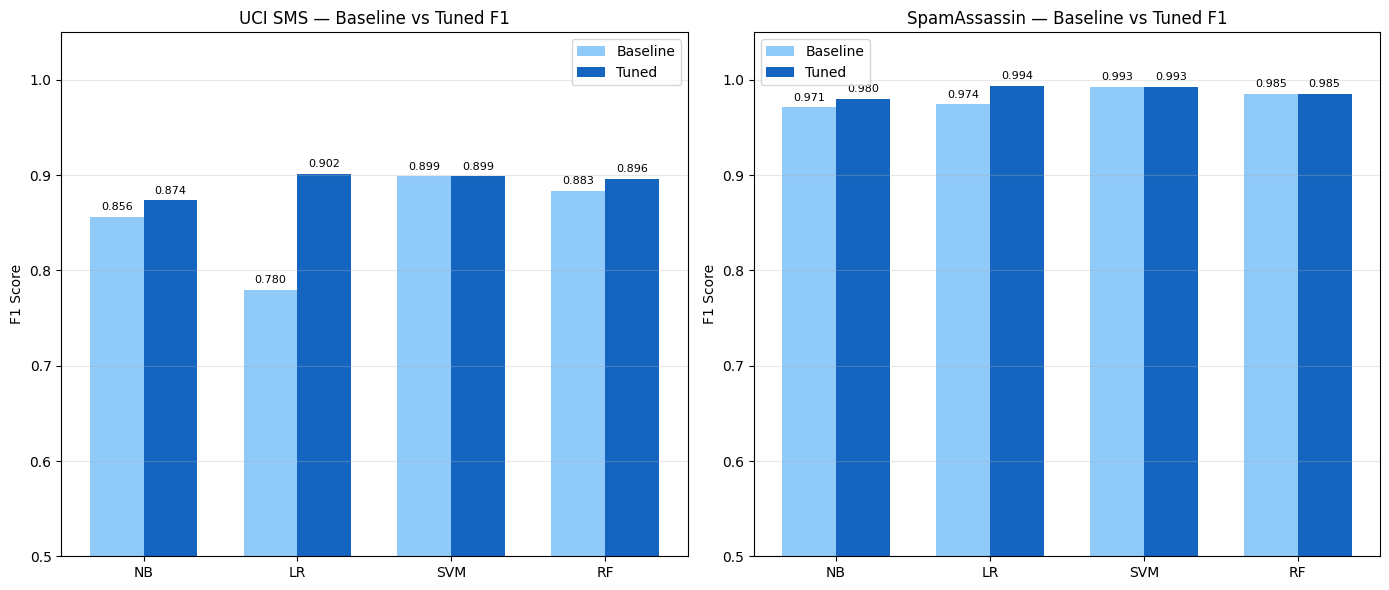

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
model_names = list(uci_baseline.keys())
short_names = ['NB', 'LR', 'SVM', 'RF']
x = np.arange(len(model_names))
width = 0.35

# UCI F1 comparison
baseline_f1 = [uci_baseline[m]['f1'] for m in model_names]
tuned_f1 = [uci_tuned_results[m]['f1'] for m in model_names]

bars1 = axes[0].bar(x - width/2, baseline_f1, width,
                    label='Baseline', color='#90CAF9')
bars2 = axes[0].bar(x + width/2, tuned_f1, width,
                    label='Tuned', color='#1565C0')
axes[0].set_title('UCI SMS — Baseline vs Tuned F1')
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_names)
axes[0].set_ylim(0.5, 1.05)
axes[0].set_ylabel('F1 Score')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)

# SpamAssassin F1 comparison
sa_baseline_f1 = [sa_baseline[m]['f1'] for m in model_names]
sa_tuned_f1 = [sa_tuned_results[m]['f1'] for m in model_names]

bars3 = axes[1].bar(x - width/2, sa_baseline_f1, width,
                    label='Baseline', color='#90CAF9')
bars4 = axes[1].bar(x + width/2, sa_tuned_f1, width,
                    label='Tuned', color='#1565C0')
axes[1].set_title('SpamAssassin — Baseline vs Tuned F1')
axes[1].set_xticks(x)
axes[1].set_xticklabels(short_names)
axes[1].set_ylim(0.5, 1.05)
axes[1].set_ylabel('F1 Score')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)
for bar in bars4:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('tuning_comparison.png')
plt.show()

In [16]:
print("=== Logistic Regression Investigation — Low Recall ===\n")

# Compare default vs balanced class weight
lr_default = LogisticRegression(max_iter=1000, random_state=42)
lr_balanced = LogisticRegression(max_iter=1000, random_state=42,
                                  class_weight='balanced')

lr_default.fit(X_uci_train, y_uci_train)
lr_balanced.fit(X_uci_train, y_uci_train)

y_pred_default = lr_default.predict(X_uci_test)
y_pred_balanced = lr_balanced.predict(X_uci_test)

print("Default LR:")
print(f"  Precision: {precision_score(y_uci_test, y_pred_default, pos_label='spam'):.4f}")
print(f"  Recall:    {recall_score(y_uci_test, y_pred_default, pos_label='spam'):.4f}")
print(f"  F1:        {f1_score(y_uci_test, y_pred_default, pos_label='spam'):.4f}")

print("\nBalanced LR:")
print(f"  Precision: {precision_score(y_uci_test, y_pred_balanced, pos_label='spam'):.4f}")
print(f"  Recall:    {recall_score(y_uci_test, y_pred_balanced, pos_label='spam'):.4f}")
print(f"  F1:        {f1_score(y_uci_test, y_pred_balanced, pos_label='spam'):.4f}")

print("\nConclusion:")
recall_improvement = recall_score(y_uci_test, y_pred_balanced, pos_label='spam') - \
                     recall_score(y_uci_test, y_pred_default, pos_label='spam')
print(f"Recall improved by {recall_improvement:.4f} with balanced class weights")
print("This confirms class imbalance was a key factor in LR's low recall")

=== Logistic Regression Investigation — Low Recall ===

Default LR:
  Precision: 0.9770
  Recall:    0.6489
  F1:        0.7798

Balanced LR:
  Precision: 0.8741
  Recall:    0.9008
  F1:        0.8872

Conclusion:
Recall improved by 0.2519 with balanced class weights
This confirms class imbalance was a key factor in LR's low recall


In [17]:
tuning_results = {
    'UCI': {
        'baseline': uci_baseline,
        'tuned': uci_tuned_results,
        'best_params': uci_best_params
    },
    'SpamAssassin': {
        'baseline': sa_baseline,
        'tuned': sa_tuned_results,
        'best_params': sa_best_params
    }
}

with open('tuning_results.json', 'w') as f:
    json.dump(tuning_results, f)

print("Tuning results saved!")

Tuning results saved!
